# N2 · VLM 评测出版级图 (VLM Eval Figure)

> 配套 10.6-L4 · 用 9.6 的 `plotstyle` 把 POPE 评测结果画成出版级图 (带误差棒), 体会
> 「会测 + 会诚实报告」。VLM 评测的诚实 = M6 + 9.4 + 9.6 + 本专题叠加。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
FIG_SRC = Path.cwd().parent.parent / "research-figures" / "src"  # 复用 9.6 plotstyle
for p in (SRC, FIG_SRC): sys.path.insert(0, str(p))
import numpy as np, pandas as pd
import vlm_eval as ve
import plotstyle as ps
ps.set_pub_style()
print('就绪 (复用 9.6 plotstyle)')

就绪 (复用 9.6 plotstyle)


## 1. 多种子评测 (VLM 也有随机性, 报方差, 9.4-L5)

In [2]:
hs = [0.0, 0.2, 0.4, 0.6, 0.8]
acc_mean, acc_sem, yes_mean, yes_sem = [], [], [], []
for h in hs:
    accs = [ve.run_pope(hallucination=h, n=300, seed=s)["accuracy"] for s in range(6)]
    yess = [ve.run_pope(hallucination=h, n=300, seed=s)["yes_rate"] for s in range(6)]
    acc_mean.append(np.mean(accs)); acc_sem.append(np.std(accs,ddof=1)/np.sqrt(6))
    yes_mean.append(np.mean(yess)); yes_sem.append(np.std(yess,ddof=1)/np.sqrt(6))
print("6 种子评测完成 (报均值±SEM)")

6 种子评测完成 (报均值±SEM)


## 2. 出版级图: 幻觉率 vs 准确率/yes-rate (带误差棒, 诚实, 9.6)

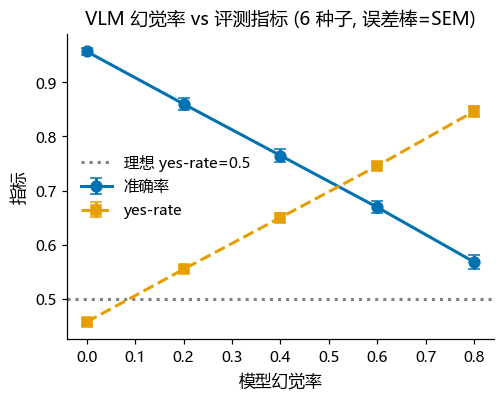

已导出出版级图 (PDF+PNG): ['pope_eval.pdf', 'pope_eval.png']


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=ps.column_figsize(width_in=5))
ax.errorbar(hs, acc_mean, yerr=acc_sem, fmt='o-', capsize=4, label='准确率', color=ps.OKABE_ITO[0])
ax.errorbar(hs, yes_mean, yerr=yes_sem, fmt='s--', capsize=4, label='yes-rate', color=ps.OKABE_ITO[1])
ax.axhline(0.5, ls=':', c='gray', label='理想 yes-rate=0.5')
ax.set_xlabel('模型幻觉率'); ax.set_ylabel('指标')
ax.set_title('VLM 幻觉率 vs 评测指标 (6 种子, 误差棒=SEM)')
ax.legend(frameon=False)
out = Path.cwd() / "_fig";
paths = ps.save_figure(fig, "pope_eval", out_dir=out)
plt.show()
print(f"已导出出版级图 (PDF+PNG): {[p.name for p in paths]}")

## 3. 诚实报告 checklist (L4): 这张图诚实吗?

In [4]:
checks = {
    "多维剖面 (非单一总分)": "本图分准确率/yes-rate 两维 (真实还应加 MMMU/MME/定位)",
    "抗幻觉指标必报": "yes-rate (POPE) 已报 ✅",
    "带方差/误差棒": "6 种子 SEM 误差棒 ✅ (9.4-L5)",
    "y 轴诚实": "从 0 起, 不截断夸大 ✅ (9.6-L4)",
    "prompt/污染声明": "真实报告需补 (本图是模拟数据)",
}
for k, v in checks.items():
    print(f"  ☑ {k}: {v}")

  ☑ 多维剖面 (非单一总分): 本图分准确率/yes-rate 两维 (真实还应加 MMMU/MME/定位)
  ☑ 抗幻觉指标必报: yes-rate (POPE) 已报 ✅
  ☑ 带方差/误差棒: 6 种子 SEM 误差棒 ✅ (9.4-L5)
  ☑ y 轴诚实: 从 0 起, 不截断夸大 ✅ (9.6-L4)
  ☑ prompt/污染声明: 真实报告需补 (本图是模拟数据)


## 4. 反思 (10.6 收口)

你把 VLM 评测做成了诚实的出版级图: **多维 + 带方差 + y 轴不截断**。带走:
- 会造 VLM (10.1-10.5) 也要会测 (10.6): 它说得对吗? 真看图吗? 会幻觉吗?
- VLM 评测诚实 = M6 评测 + 9.4 实验严谨 + 9.6 诚实图 + 本专题幻觉, 全部叠加。
- 评测是 VLM 工程的良心 —— 不自欺才能真进步 (接 9.5/9.6 诚实主线)。

> **M10.6 收口**。交棒 10.7 (Capstone): 把 10.1-10.6 装配成完整 mini-VLM 流水线,
> 用 9.3 gap 雷达把 M10 变成你的 PhD 研究入口 —— 下一专题 `multimodal-graduation`。